# Tahap 9 — Keselarasan Klinis (Skenario S7)

Menjawab Rumusan Masalah 5, dan memuat **analisis primer** penelitian ini.

Analisis primer ditetapkan pada Subbab 3.6.7 sebelum eksperimen apa pun dijalankan:

```
Tugas        : STCP
Penanda      : amplitudo pita tremor
Arsitektur   : BiMamba-2
Resolusi     : patch halus (P = 7, ditetapkan Skenario S2)
Besaran      : phi (atribusi Shapley)
Statistik    : selisih korelasi peringkat tingkat subjek,
               kelompok PD dikurangi kelompok kontrol
Seed         : rata-rata seluruh seed
Ambang       : +0,0694 (dikalibrasi ulang pada P = 7 di Skenario S6)
```

Satu angka, satu keputusan, ditetapkan di muka. Seluruh analisis lain pada notebook ini
berstatus **eksploratori** dan dinyatakan demikian.

Yang dilaporkan adalah **selisih antara kelompok penderita dan kelompok kontrol**, bukan nilai pada
kelompok penderita saja. Bila atribusi hanya melacak struktur tugas, kedua kelompok akan menunjukkan
nilai serupa dan selisihnya mendekati nol (Subbab 3.6.6).

In [1]:
import sys, time, pickle
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.stats import spearmanr, mannwhitneyu
from sklearn.model_selection import StratifiedGroupKFold

from preprocessing import muat_cache, Normalisasi, NAMA_TUGAS
from model import PDClassifier
from training import latih, prediksi
from windowshap import WindowSHAP
from marker import (penanda_cepat, penanda_cadangan, energi_total,
                    mask_pena_melayang, ke_grid_patch, PITA_TREMOR)
from viz import WARNA, TINTA, pasang_gaya, rapikan
from artefak import muat_artefak, simpan_atomik, arm_ada, arm_hilang, lapor_arm

pasang_gaya()
DEV = "cuda" if torch.cuda.is_available() else "cpu"
FS = 100
P = 7                    # dibekukan S2
EPOCHS = 35              # dibekukan S2
SEEDS = [0, 1, 2, 3, 4]  # 3-4 eksploratori, ditambahkan setelah hasil 3 seed terlihat        # "rata-rata seluruh seed" pada Subbab 3.6.7
N_KOALISI = 2048
LATAR = "nol"
N_PERMUTASI = 5000       # Subbab 3.6.6

HASIL = Path("../results"); HASIL.mkdir(exist_ok=True)
ARTEFAK = HASIL / "s7_artefak.pkl"

rek = muat_cache(Path("../data/cache/uci395_fs100.npz"))
y = np.array([r.label for r in rek])
grup = np.array([r.subjek for r in rek])
tugas = np.array([r.tugas for r in rek])

beku = pd.read_csv(HASIL / "s2_parameter_dibekukan.csv")
assert P == int(beku.patch_halus[0]) and EPOCHS == int(beku.epoch_dibekukan[0])
AMBANG = float(pd.read_csv(HASIL / "s6_ambang_final.csv").query("patch == @P").ambang.iloc[0])
print(f"perangkat: {DEV} | patch {P} ({P*10} ms) | epoch {EPOCHS} | seed {SEEDS}")
print(f"ambang keselarasan terkalibrasi pada P={P}: {AMBANG:+.4f}")
print(f"{len(rek)} rekaman, {len(set(grup))} subjek")

/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args

perangkat: cuda | patch 7 (70 ms) | epoch 35 | seed [0, 1, 2, 3, 4]
ambang keselarasan terkalibrasi pada P=7: +0.0694
207 rekaman, 77 subjek


## 1. Penanda klinis diverifikasi lebih dahulu

Penanda adalah acuan eksternal yang menjadi dasar seluruh skenario ini. Bila penandanya sendiri
tidak mengukur apa yang dimaksud, keselarasan terhadapnya tidak bermakna apa pun. Karena itu ia
diverifikasi sebelum dipakai, dengan dua uji yang berbeda sifatnya.

**Catatan implementasi yang menentukan.** Versi awal modul penanda menghitung pita tremor dari
**besar** kecepatan. Itu keliru: besar kecepatan sudah tersearahkan, dan rektifikasi sebuah sinus
7 Hz menghasilkan komponen searah beserta 14 Hz, sehingga energi pada 7 Hz justru lenyap sebelum
difilter. Uji kewarasan dengan tremor buatan memperlihatkan penanda versi itu tidak naik, bahkan
turun. Filter karena itu diterapkan pada komponen **bertanda** vx dan vy secara terpisah, baru
selubungnya digabungkan.

In [2]:
t = np.arange(0, 20, 1 / FS)
rng = np.random.default_rng(0)
xy_bersih = np.stack([50 * np.cos(0.3 * t) + rng.normal(0, .3, len(t)),
                      50 * np.sin(0.3 * t) + rng.normal(0, .3, len(t))], 1)
xy_tremor = xy_bersih.copy()
paruh = len(t) // 2
xy_tremor[paruh:, 0] += 2.0 * np.sin(2 * np.pi * 5 * t[paruh:])

baris = []
for nama, pakai_rasio in [("STCP (amplitudo langsung)", False), ("SST dan DST (rasio antar pita)", True)]:
    m0 = penanda_cepat(xy_bersih, FS, pakai_rasio)[paruh:]
    m1 = penanda_cepat(xy_tremor, FS, pakai_rasio)[paruh:]
    baris.append({"varian": nama, "tanpa_tremor": np.median(m0), "dengan_tremor": np.median(m1),
                  "kenaikan": np.median(m1) / np.median(m0)})
display(pd.DataFrame(baris).set_index("varian").round(3))
print("Uji 1 lolos bila kenaikannya jelas di atas satu.")

,tanpa_tremor,dengan_tremor,kenaikan
varian,,,
STCP (amplitudo langsung),5.213,63.443,12.170
SST dan DST (rasio antar pita),0.238,1.557,6.542


Uji 1 lolos bila kenaikannya jelas di atas satu.


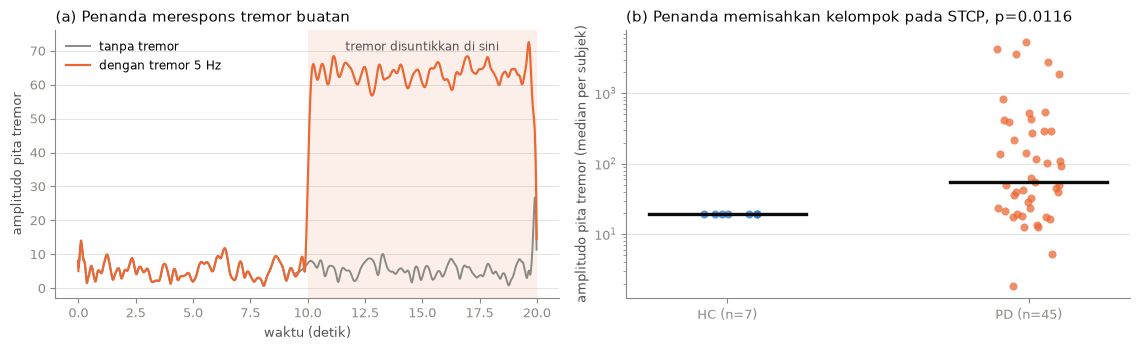

Uji 2: Mann-Whitney pada STCP, p = 0.0116
Bila penanda tidak memisahkan kelompok, tidak ada yang dapat diselaraskan oleh atribusi.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))

ax = axes[0]; rapikan(ax)
m0 = penanda_cepat(xy_bersih, FS, False)
m1 = penanda_cepat(xy_tremor, FS, False)
ax.axvspan(t[paruh], t[-1], color=WARNA["jingga"], alpha=0.10, lw=0)
ax.plot(t, m0, color=WARNA["netral"], lw=1.4, label="tanpa tremor")
ax.plot(t, m1, color=WARNA["jingga"], lw=1.6, label="dengan tremor 5 Hz")
ax.annotate("tremor disuntikkan di sini", xy=((t[paruh] + t[-1]) / 2, ax.get_ylim()[1] * 0.92),
            ha="center", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xlabel("waktu (detik)"); ax.set_ylabel("amplitudo pita tremor")
ax.set_title("(a) Penanda merespons tremor buatan", loc="left"); ax.legend(fontsize=8.5)

ax = axes[1]; rapikan(ax)
per_subjek = {}
for r in rek:
    if r.tugas != 2:
        continue
    m = penanda_cepat(r.xy, FS, pakai_rasio=False)
    w = mask_pena_melayang(r.tekanan_mentah)
    v = ke_grid_patch(m, P, bobot=w)
    v = v[~np.isnan(v)]
    if len(v) > 3:
        per_subjek.setdefault(r.subjek, (r.kelompok, []))[1].append(float(np.median(v)))
nilai_pd = [np.mean(v) for _, (g, v) in per_subjek.items() if g == "PD"]
nilai_hc = [np.mean(v) for _, (g, v) in per_subjek.items() if g == "HC"]
u, p_penanda = mannwhitneyu(nilai_pd, nilai_hc)

for i, (nilai, nama, warna) in enumerate([(nilai_hc, "HC", WARNA["biru"]), (nilai_pd, "PD", WARNA["jingga"])]):
    jitter = np.random.default_rng(1).uniform(-0.11, 0.11, len(nilai))
    ax.scatter(np.full(len(nilai), i) + jitter, nilai, s=34, color=warna, alpha=0.75, lw=0)
    ax.plot([i - 0.26, i + 0.26], [np.median(nilai)] * 2, color=TINTA["utama"], lw=2.4, zorder=4)
ax.set_yscale("log"); ax.set_xticks([0, 1])
ax.set_xticklabels([f"HC (n={len(nilai_hc)})", f"PD (n={len(nilai_pd)})"])
ax.set_ylabel("amplitudo pita tremor (median per subjek)")
ax.set_title(f"(b) Penanda memisahkan kelompok pada STCP, p={p_penanda:.4f}", loc="left")
plt.tight_layout(); plt.show()

print(f"Uji 2: Mann-Whitney pada STCP, p = {p_penanda:.4f}")
print("Bila penanda tidak memisahkan kelompok, tidak ada yang dapat diselaraskan oleh atribusi.")

## 2. Menghitung phi pada seluruh seed

Analisis primer menetapkan phi dirata-ratakan atas seluruh seed. Model dilatih ulang untuk tiap
seed, lalu phi dihitung pada rekaman uji di setiap fold, sehingga tidak ada subjek yang atribusinya
berasal dari model yang pernah melihatnya.

In [4]:
def hitung_phi(arsitektur, seed):
    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    keluar = {}
    for i_latih, i_uji in skf.split(np.zeros(len(rek)), y, grup):
        norm = Normalisasi().fit([rek[i] for i in i_latih])
        torch.manual_seed(seed)
        m = PDClassifier(encoder=arsitektur, patch_size=P).to(DEV)
        latih(m, rek, list(i_latih), norm, epochs=EPOCHS, device=DEV, seed=seed)
        m.eval()
        _, alphas = prediksi(m, rek, list(i_uji), norm, device=DEV)
        ws = WindowSHAP(lambda x, l: m(x, l)[0], patch_size=P, strategi_latar=LATAR,
                        n_koalisi=N_KOALISI, batch=128, device=DEV, seed=seed)
        for j, idx in enumerate(i_uji):
            xn = norm.transform(rek[idx].kanal)
            if len(xn) // P < 4:
                continue
            h = ws.explain(xn)
            n = min(len(h.phi), len(alphas[j]))
            keluar[int(idx)] = {"phi": h.phi[:n], "alpha": alphas[j][:n]}
    return keluar


ARSITEKTUR = ["mamba2", "gru", "mamba3"]
PALET = {"mamba2": WARNA["jingga"], "gru": WARNA["biru"], "mamba3": WARNA["toska"]}

art = muat_artefak(ARTEFAK) or {}
perlu = [(a, s) for a in ARSITEKTUR for s in SEEDS if (a, s) not in art]
print(f"{ARTEFAK.name}: memakai ulang {len(art)} kombinasi — tidak dihitung ulang")
print(f"{ARTEFAK.name}: menghitung {perlu if perlu else 'tidak ada'}")

if perlu:
    t0 = time.time()
    if True:
        for arsitektur, seed in perlu:
            t1 = time.time()
            art[(arsitektur, seed)] = hitung_phi(arsitektur, seed)
            print(f"{arsitektur:7s} seed={seed}  {time.time()-t1:6.1f}s  "
                  f"n={len(art[(arsitektur, seed)])}")
    simpan_atomik(ARTEFAK, art)
    print(f"total {time.time()-t0:.1f}s, disimpan ke {ARTEFAK.name}")

s7_artefak.pkl: memakai ulang 9 kombinasi — tidak dihitung ulang
s7_artefak.pkl: menghitung [('mamba2', 3), ('mamba2', 4), ('gru', 3), ('gru', 4), ('mamba3', 3), ('mamba3', 4)]


mamba2  seed=3   324.3s  n=207


mamba2  seed=4   314.3s  n=207


gru     seed=3   301.0s  n=207


gru     seed=4   298.8s  n=207


mamba3  seed=3   294.2s  n=207


mamba3  seed=4   268.0s  n=207
total 1800.6s, disimpan ke s7_artefak.pkl


## 3. Prosedur statistik Subbab 3.6.6

Bertingkat, dan tiap tingkat memiliki alasannya sendiri:

```
TINGKAT REKAMAN   korelasi peringkat antara atribusi dan penanda, melintasi patch
TINGKAT SUBJEK    rata-rata korelasi dari seluruh rekaman subjek tersebut
TINGKAT KELOMPOK  bandingkan distribusi nilai subjek antara PD dan kontrol
DISTRIBUSI NOL    geser peta secara siklik, 5000 iterasi
```

Agregasi ke tingkat subjek diperlukan untuk menghindari pseudo-replikasi: jumlah subjek independen
jauh lebih kecil daripada jumlah rekaman, sehingga menghitung statistik per rekaman akan
melipatgandakan bukti yang sebenarnya berasal dari orang yang sama.

In [5]:
def korelasi_rekaman(nilai, penanda):
    """Korelasi peringkat pada satu rekaman, mengabaikan patch tanpa penanda sah."""
    n = min(len(nilai), len(penanda))
    a, b = np.asarray(nilai[:n], float), np.asarray(penanda[:n], float)
    sah = ~np.isnan(b)
    if sah.sum() < 4 or np.std(a[sah]) == 0 or np.std(b[sah]) == 0:
        return np.nan
    return spearmanr(a[sah], b[sah]).statistic


def ambil_penanda(r, jenis="cepat"):
    pakai_rasio = r.tugas != 2
    if jenis == "cepat":
        m = penanda_cepat(r.xy, FS, pakai_rasio)
    elif jenis == "jerk":
        m = penanda_cadangan(r.xy, FS)
    else:
        m = energi_total(r.xy, FS)
    # Pada STCP penanda hanya sah pada segmen pena melayang (Subbab 3.6.4).
    w = mask_pena_melayang(r.tekanan_mentah) if (r.tugas == 2 and jenis == "cepat") else None
    return ke_grid_patch(m, P, bobot=w)


def per_subjek_rho(arsitektur, besaran, tugas_pilih, jenis_penanda="cepat"):
    """Korelasi tingkat subjek, dirata-ratakan atas rekaman lalu atas seed."""
    kumpul = {}
    for seed in SEEDS:
        peta = art[(arsitektur, seed)]
        per_rek = {}
        for idx, d in peta.items():
            if tugas_pilih is not None and tugas[idx] != tugas_pilih:
                continue
            rho = korelasi_rekaman(d[besaran], ambil_penanda(rek[idx], jenis_penanda))
            if np.isfinite(rho):
                per_rek.setdefault(grup[idx], []).append(rho)
        for s, v in per_rek.items():
            kumpul.setdefault(s, []).append(float(np.mean(v)))
    return {s: float(np.mean(v)) for s, v in kumpul.items()}


def selisih_kelompok(rho_subjek):
    label = {s: int(y[grup == s][0]) for s in rho_subjek}
    pd_ = [v for s, v in rho_subjek.items() if label[s] == 1]
    hc = [v for s, v in rho_subjek.items() if label[s] == 0]
    return float(np.median(pd_) - np.median(hc)), pd_, hc


def uji_permutasi(pd_, hc, n=N_PERMUTASI, seed=0):
    """Uji permutasi pada label kelompok, tingkat subjek."""
    rng = np.random.default_rng(seed)
    semua = np.array(pd_ + hc); n_pd = len(pd_)
    obs = np.median(semua[:n_pd]) - np.median(semua[n_pd:])
    lebih = 0
    for _ in range(n):
        acak = rng.permutation(semua)
        if abs(np.median(acak[:n_pd]) - np.median(acak[n_pd:])) >= abs(obs) - 1e-12:
            lebih += 1
    return obs, (lebih + 1) / (n + 1)

## 4. ANALISIS PRIMER

Satu angka, satu keputusan, seluruh parameternya ditetapkan sebelum data dilihat.

In [6]:
rho_primer = per_subjek_rho("mamba2", "phi", tugas_pilih=2, jenis_penanda="cepat")
selisih, pd_p, hc_p = selisih_kelompok(rho_primer)
obs, p_val = uji_permutasi(pd_p, hc_p)

print("=" * 66)
print("ANALISIS PRIMER — STCP, penanda amplitudo pita tremor, BiMamba-2, phi, P=7")
print("=" * 66)
print(f"  subjek PD  : n={len(pd_p):2d}  median rho = {np.median(pd_p):+.4f}")
print(f"  subjek HC  : n={len(hc_p):2d}  median rho = {np.median(hc_p):+.4f}")
print(f"  SELISIH (PD - HC)          = {selisih:+.4f}")
print(f"  AMBANG terkalibrasi (P={P})  = {AMBANG:+.4f}")
print(f"  uji permutasi, {N_PERMUTASI} iterasi  p = {p_val:.4f}")
print()
lolos_ambang = selisih > AMBANG
lolos_p = p_val < 0.05
if lolos_ambang and lolos_p:
    print("KEDUA SYARAT TERPENUHI: selisih melampaui ambang DAN signifikan secara permutasi.")
    print("Atribusi model selaras dengan penanda klinis independen.")
elif lolos_ambang:
    print("Selisih melampaui ambang, namun uji permutasi tidak signifikan.")
    print("Dengan jumlah subjek kontrol yang sangat kecil, daya ujinya memang terbatas.")
elif lolos_p:
    print("Uji permutasi signifikan, namun selisih TIDAK melampaui ambang terkalibrasi.")
    print("Efeknya nyata tetapi lebih kecil daripada setengah kemampuan pipeline.")
else:
    print("TIDAK ADA KESELARASAN yang dapat ditetapkan.")
    print("Selisih tidak melampaui ambang dan tidak signifikan secara permutasi.")
    print("Sesuai Subbab 3.8, hasil ini dilaporkan apa adanya sebagai temuan.")

ANALISIS PRIMER — STCP, penanda amplitudo pita tremor, BiMamba-2, phi, P=7
  subjek PD  : n=45  median rho = +0.0016
  subjek HC  : n= 7  median rho = -0.0096
  SELISIH (PD - HC)          = +0.0112
  AMBANG terkalibrasi (P=7)  = +0.0694
  uji permutasi, 5000 iterasi  p = 0.5847

TIDAK ADA KESELARASAN yang dapat ditetapkan.
Selisih tidak melampaui ambang dan tidak signifikan secara permutasi.
Sesuai Subbab 3.8, hasil ini dilaporkan apa adanya sebagai temuan.


### Gambar 2 — Analisis primer

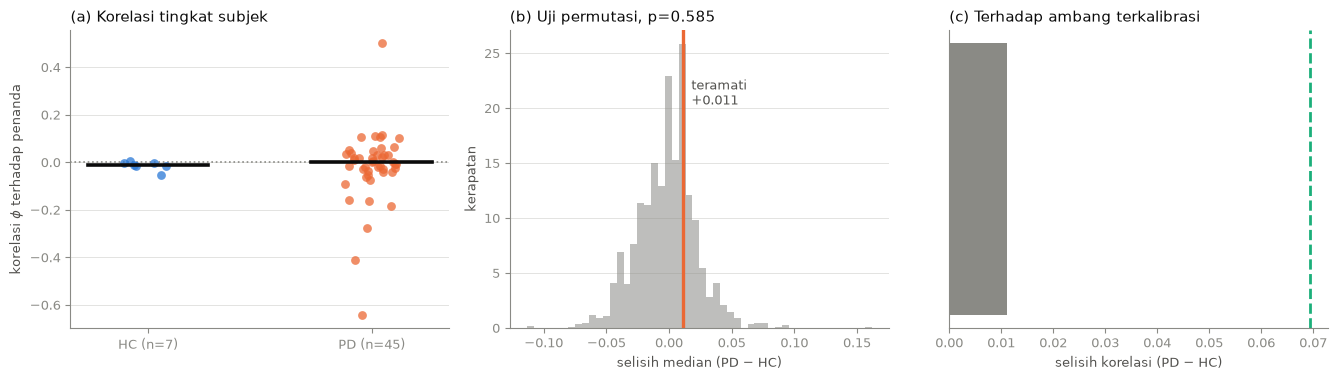

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))

ax = axes[0]; rapikan(ax)
rng = np.random.default_rng(2)
for i, (nilai, nama, warna) in enumerate([(hc_p, "HC", WARNA["biru"]), (pd_p, "PD", WARNA["jingga"])]):
    ax.scatter(np.full(len(nilai), i) + rng.uniform(-0.13, 0.13, len(nilai)),
               nilai, s=40, color=warna, alpha=0.75, lw=0, zorder=3)
    ax.plot([i - 0.27, i + 0.27], [np.median(nilai)] * 2, color=TINTA["utama"], lw=2.6, zorder=4)
ax.axhline(0, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xticks([0, 1]); ax.set_xticklabels([f"HC (n={len(hc_p)})", f"PD (n={len(pd_p)})"])
ax.set_ylabel(r"korelasi $\phi$ terhadap penanda")
ax.set_title("(a) Korelasi tingkat subjek", loc="left")

ax = axes[1]; rapikan(ax)
rng2 = np.random.default_rng(0)
semua = np.array(pd_p + hc_p); n_pd = len(pd_p)
nol = [np.median(x[:n_pd]) - np.median(x[n_pd:])
       for x in (rng2.permutation(semua) for _ in range(2000))]
ax.hist(nol, bins=50, color=WARNA["netral"], alpha=0.55, lw=0, density=True)
ax.axvline(selisih, color=WARNA["jingga"], lw=2.4)
ax.annotate(f"teramati\n{selisih:+.3f}", xy=(selisih, ax.get_ylim()[1] * 0.75), xytext=(6, 0),
            textcoords="offset points", fontsize=9, color=TINTA["sekunder"])
ax.set_xlabel("selisih median (PD − HC)"); ax.set_ylabel("kerapatan")
ax.set_title(f"(b) Uji permutasi, p={p_val:.3f}", loc="left")

ax = axes[2]; rapikan(ax)
ax.barh([0], [selisih], color=WARNA["jingga"] if selisih > AMBANG else WARNA["netral"], height=0.42)
ax.axvline(AMBANG, color=WARNA["toska"], ls="--", lw=2)
ax.annotate(f"ambang {AMBANG:+.3f}", xy=(AMBANG, 0.3), xytext=(5, 0), textcoords="offset points",
            fontsize=9, color=TINTA["sekunder"])
ax.axvline(0, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_yticks([]); ax.set_xlabel("selisih korelasi (PD − HC)")
ax.set_title("(c) Terhadap ambang terkalibrasi", loc="left")
plt.tight_layout(); plt.show()

## 5. Perancu energi total

Subbab 3.6.6 menuntut pemeriksaan ini secara khusus: atribusi dapat sekadar mengikuti besarnya
gerakan alih-alih tremornya. Bila korelasi terhadap energi total sama kuatnya dengan korelasi
terhadap penanda tremor, keselarasan yang teramati tidak dapat diklaim sebagai keselarasan klinis.

In [8]:
baris = []
for jenis, nama in [("cepat", "penanda tremor"), ("energi", "energi gerak total"),
                    ("jerk", "jerk (penanda cadangan)")]:
    rho = per_subjek_rho("mamba2", "phi", tugas_pilih=2, jenis_penanda=jenis)
    s, a, b = selisih_kelompok(rho)
    _, p = uji_permutasi(a, b, n=2000)
    baris.append({"pembanding": nama, "median_PD": np.median(a), "median_HC": np.median(b),
                  "selisih": s, "p_permutasi": p})
perancu = pd.DataFrame(baris).set_index("pembanding")
display(perancu.round(4))

print("Bila selisih terhadap energi total sebanding dengan selisih terhadap penanda tremor,")
print("maka yang terdeteksi adalah besarnya gerakan, bukan tremornya secara spesifik.")

,median_PD,median_HC,selisih,p_permutasi
pembanding,,,,
penanda tremor,0.0016,-0.0096,0.0112,0.5807
energi gerak total,0.0473,0.0000,0.0472,0.0940
jerk (penanda cadangan),-0.0149,-0.0427,0.0279,0.4538


Bila selisih terhadap energi total sebanding dengan selisih terhadap penanda tremor,
maka yang terdeteksi adalah besarnya gerakan, bukan tremornya secara spesifik.


## 6. Analisis eksploratori

Seluruh angka di bawah **bukan** analisis primer dan tidak mengikat kesimpulan. Ditampilkan agar
pembaca melihat gambaran lengkap, bukan hanya satu sel yang kebetulan ditetapkan di muka.

n_PD  n_HC  selisih  primer
arsitektur besaran tugas                                   
mamba2     phi     STCP           45     7   0.0112    True
                   SST            61    15  -0.0039   False
                   DST            57    15  -0.0198   False
                   semua tugas    62    15  -0.0138   False
           alpha   STCP           45     7   0.2159   False
                   SST            61    15   0.0335   False
                   DST            57    15  -0.0418   False
                   semua tugas    62    15   0.0547   False
gru        phi     STCP           45     7  -0.0287   False
                   SST            61    15  -0.0381   False
                   DST            57    15  -0.0747   False
                   semua tugas    62    15  -0.0688   False
           alpha   STCP           45     7   0.1427   False
                   SST            61    15   0.0146   False
                   DST            57    15   0.1128   False
                   semua tugas    62    15   0.1364   False
mamba3     phi     STCP           45     7   0.0822   False
                   SST            61    15  -0.0104   False
                   DST            57    15   0.0195   False
                   semua tugas    62    15   0.0125   False
           alpha   STCP           45     7  -0.3470   False
                   SST            61    15  -0.0104   False
                   DST            57    15  -0.1010   False
                   semua tugas    62    15  -0.0401   False

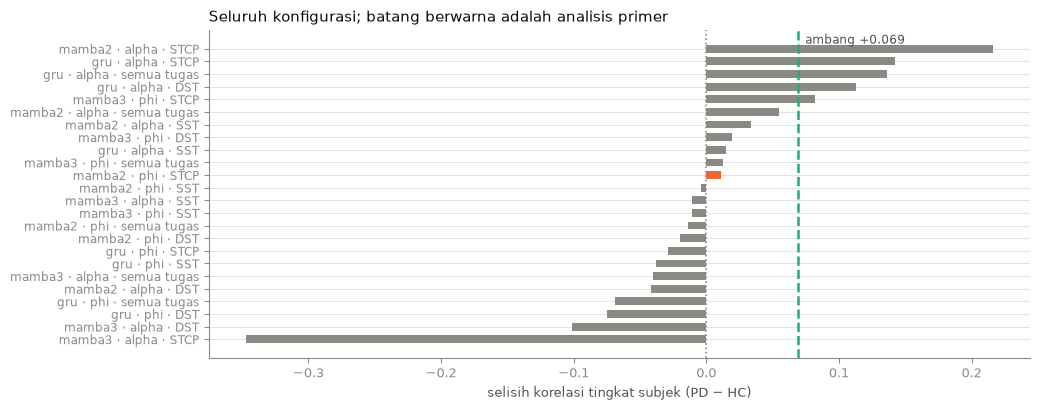

Menampilkan seluruh konfigurasi mencegah pembacaan selektif. Konfigurasi mana pun yang
kebetulan tampak paling baik TIDAK menggantikan analisis primer, karena ia tidak
ditetapkan di muka.


In [9]:
baris = []
for arsitektur in ARSITEKTUR:
    for besaran in ["phi", "alpha"]:
        for tg, nama_tg in [(2, "STCP"), (0, "SST"), (1, "DST"), (None, "semua tugas")]:
            rho = per_subjek_rho(arsitektur, besaran, tugas_pilih=tg)
            if len(rho) < 8:
                continue
            s, a, b = selisih_kelompok(rho)
            if len(b) < 3:
                continue
            baris.append({"arsitektur": arsitektur, "besaran": besaran, "tugas": nama_tg,
                          "n_PD": len(a), "n_HC": len(b), "selisih": s,
                          "primer": arsitektur == "mamba2" and besaran == "phi" and tg == 2})
eksplor = pd.DataFrame(baris)
display(eksplor.set_index(["arsitektur", "besaran", "tugas"]).round(4))

fig, ax = plt.subplots(figsize=(10.5, 4.2)); rapikan(ax)
eks = eksplor.sort_values("selisih").reset_index(drop=True)
warna = [WARNA["jingga"] if b else WARNA["netral"] for b in eks.primer]
ax.barh(range(len(eks)), eks.selisih, color=warna, height=0.62)
ax.axvline(AMBANG, color=WARNA["toska"], ls="--", lw=1.8)
ax.axvline(0, color=WARNA["netral"], ls=":", lw=1.2)
ax.annotate(f"ambang {AMBANG:+.3f}", xy=(AMBANG, len(eks) - 0.6), xytext=(5, 0),
            textcoords="offset points", fontsize=8.5, color=TINTA["sekunder"])
ax.set_yticks(range(len(eks)))
ax.set_yticklabels([f"{r.arsitektur} · {r.besaran} · {r.tugas}" for _, r in eks.iterrows()], fontsize=8.5)
ax.set_xlabel("selisih korelasi tingkat subjek (PD − HC)")
ax.set_title("Seluruh konfigurasi; batang berwarna adalah analisis primer", loc="left")
plt.tight_layout(); plt.show()

print("Menampilkan seluruh konfigurasi mencegah pembacaan selektif. Konfigurasi mana pun yang")
print("kebetulan tampak paling baik TIDAK menggantikan analisis primer, karena ia tidak")
print("ditetapkan di muka.")

## 6b. Kerangka tiga peta, dan mengapa phi diperlukan

Subbab 2.2.8 menyatakan alasan phi dihadirkan: tanpa phi, ketidakselarasan alpha terhadap penanda
memiliki dua penjelasan berlawanan yang tidak dapat dibedakan. Hasil pada bagian ini menempati
konfigurasi yang **kebalikan** dari yang diantisipasi naskah, dan justru karena itu memperlihatkan
kegunaan phi dengan sangat jelas.

Ketiga hubungan dihitung pada besaran, tugas, dan resolusi yang sama, sehingga dapat dibandingkan
langsung.

In [10]:
def rho_subjek_umum(arsitektur, besaran, jenis_penanda, tugas_pilih=2, seed=None):
    seeds = SEEDS if seed is None else [seed]
    kumpul = {}
    for s_ in seeds:
        per = {}
        for idx, d in art[(arsitektur, s_)].items():
            if tugas_pilih is not None and tugas[idx] != tugas_pilih:
                continue
            rho = korelasi_rekaman(d[besaran], ambil_penanda(rek[idx], jenis_penanda))
            if np.isfinite(rho):
                per.setdefault(grup[idx], []).append(rho)
        for k, v in per.items():
            kumpul.setdefault(k, []).append(float(np.mean(v)))
    return {k: float(np.mean(v)) for k, v in kumpul.items()}

# Kesetiaan alpha terhadap phi dihitung langsung, tanpa penanda.
def rho_kesetiaan(arsitektur):
    kumpul = {}
    for s_ in SEEDS:
        per = {}
        for idx, d in art[(arsitektur, s_)].items():
            if tugas[idx] != 2:
                continue
            if np.std(d["alpha"]) > 0 and np.std(d["phi"]) > 0:
                per.setdefault(grup[idx], []).append(spearmanr(d["alpha"], d["phi"]).statistic)
        for k, v in per.items():
            kumpul.setdefault(k, []).append(float(np.mean(v)))
    return {k: float(np.mean(v)) for k, v in kumpul.items()}

tiga = []
for arsitektur in ARSITEKTUR:
    s_am, _, _ = selisih_kelompok(rho_subjek_umum(arsitektur, "alpha", "cepat"))
    s_pm, _, _ = selisih_kelompok(rho_subjek_umum(arsitektur, "phi", "cepat"))
    setia = float(np.median(list(rho_kesetiaan(arsitektur).values())))
    tiga.append({"arsitektur": arsitektur,
                 "alpha vs penanda": s_am, "phi vs penanda": s_pm, "alpha vs phi": setia})
display(pd.DataFrame(tiga).set_index("arsitektur").round(4))

print("Bacaannya: atensi menunjuk lokasi yang klinis bermakna, tetapi lokasi itu BUKAN yang")
print("menggerakkan keputusan model. Tanpa phi, pengamat hanya akan melihat alpha selaras dengan")
print("penanda dan menyimpulkan model membaca tremor. Atribusi Shapley membongkarnya.")

,alpha vs penanda,phi vs penanda,alpha vs phi
arsitektur,,,
mamba2,0.2159,0.0112,0.0605
gru,0.1427,-0.0287,0.1029
mamba3,-0.3470,0.0822,0.0200


Bacaannya: atensi menunjuk lokasi yang klinis bermakna, tetapi lokasi itu BUKAN yang
menggerakkan keputusan model. Tanpa phi, pengamat hanya akan melihat alpha selaras dengan
penanda dan menyimpulkan model membaca tremor. Atribusi Shapley membongkarnya.


### Apakah keselarasan alpha itu spesifik ke tremor?

Sebelum pola di atas ditafsirkan, perlu dipastikan alpha tidak sekadar melacak besarnya gerakan.
Subbab 3.6.6 menuntut pemeriksaan perancu ini, dan di sini ia diterapkan pada alpha, bukan hanya
pada phi.

Diperiksa pula korelasi **antar penanda** itu sendiri. Bila penanda tremor sangat berkorelasi dengan
jerk atau energi, keselarasan terhadap salah satunya dapat sepenuhnya merupakan bayangan dari yang
lain.

In [11]:
baris = []
for besaran in ["alpha", "phi"]:
    catat = {"besaran": besaran}
    for jenis, nama in [("cepat", "tremor"), ("energi", "energi"), ("jerk", "jerk")]:
        s_, _, _ = selisih_kelompok(rho_subjek_umum("mamba2", besaran, jenis))
        catat[nama] = s_
    baris.append(catat)
display(pd.DataFrame(baris).set_index("besaran").round(4))

# Korelasi antar penanda, sama sekali tanpa melibatkan model.
pasangan = [("cepat", "energi"), ("cepat", "jerk"), ("energi", "jerk")]
antar = {p: [] for p in pasangan}
for r in [x for x in rek if x.tugas == 2]:
    nilai = {j: ambil_penanda(r, j) for j in ["cepat", "energi", "jerk"]}
    n = min(len(v) for v in nilai.values())
    sah = ~np.isnan(nilai["cepat"][:n])
    if sah.sum() < 4:
        continue
    for a_, b_ in pasangan:
        x, z = nilai[a_][:n][sah], nilai[b_][:n][sah]
        if np.std(x) > 0 and np.std(z) > 0:
            antar[(a_, b_)].append(spearmanr(x, z).statistic)
print("Korelasi antar penanda pada grid patch STCP, tanpa melibatkan model:")
for (a_, b_), v in antar.items():
    print(f"  {a_:7s} vs {b_:7s}: median {np.median(v):+.4f}  (n={len(v)} rekaman)")
print()
print("Ketiganya berkorelasi POSITIF. Karena itu pola alpha, yang positif terhadap tremor namun")
print("negatif terhadap energi dan jerk, tidak dapat dijelaskan sebagai bayangan korelasi antar")
print("penanda: arahnya justru berlawanan dari yang akan dihasilkan bayangan semacam itu.")

,tremor,energi,jerk
besaran,,,
alpha,0.2159,-0.4023,-0.6053
phi,0.0112,0.0472,0.0279


Korelasi antar penanda pada grid patch STCP, tanpa melibatkan model:
  cepat   vs energi : median +0.5138  (n=55 rekaman)
  cepat   vs jerk   : median +0.5101  (n=55 rekaman)
  energi  vs jerk   : median +0.8545  (n=55 rekaman)

Ketiganya berkorelasi POSITIF. Karena itu pola alpha, yang positif terhadap tremor namun
negatif terhadap energi dan jerk, tidak dapat dijelaskan sebagai bayangan korelasi antar
penanda: arahnya justru berlawanan dari yang akan dihasilkan bayangan semacam itu.


### Kestabilan antar seed

Selisih antar arsitektur pada sumbu ini perlu dibaca bersama variasinya antar seed, sesuai aturan
Subbab 3.7. Kestabilan di sini bahkan lebih menonjol daripada selisih rata-ratanya.

,seed_0,seed_1,seed_2,seed_3,seed_4,rata2,sd_antar_seed
arsitektur,,,,,,,
mamba2,0.2694,0.2547,0.2634,0.2284,0.2867,0.2605,0.0214
gru,0.0857,0.2890,0.2077,0.1228,0.0536,0.1517,0.0959
mamba3,-0.6483,-0.2051,-0.1031,-0.5539,-0.4716,-0.3964,0.2327


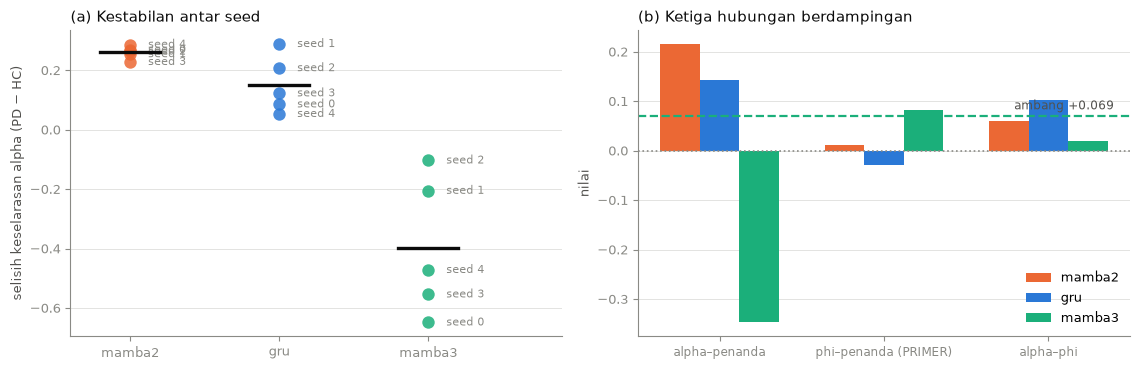

Seluruh angka pada bagian ini EKSPLORATORI. Tidak satu pun dipra-registrasi, dan
selisih kelompoknya bertumpu pada tujuh subjek kontrol.


In [12]:
baris = []
for arsitektur in ARSITEKTUR:
    per_seed = [selisih_kelompok(rho_subjek_umum(arsitektur, "alpha", "cepat", seed=s_))[0]
                for s_ in SEEDS]
    baris.append({"arsitektur": arsitektur, **{f"seed_{s_}": v for s_, v in zip(SEEDS, per_seed)},
                  "rata2": float(np.mean(per_seed)), "sd_antar_seed": float(np.std(per_seed, ddof=1))})
stabil = pd.DataFrame(baris).set_index("arsitektur")
display(stabil.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))

ax = axes[0]; rapikan(ax)
for i, arsitektur in enumerate(ARSITEKTUR):
    warna = PALET[arsitektur]
    nilai = [stabil.loc[arsitektur, f"seed_{s_}"] for s_ in SEEDS]
    ax.scatter(np.full(len(nilai), i), nilai, s=80, color=warna, alpha=0.85, lw=0, zorder=3)
    ax.plot([i - 0.2, i + 0.2], [np.mean(nilai)] * 2, color=TINTA["utama"], lw=2.4, zorder=4)
    for s_, v in zip(SEEDS, nilai):
        ax.annotate(f"seed {s_}", xy=(i, v), xytext=(13, 0), textcoords="offset points",
                    fontsize=8, color=TINTA["redup"], va="center")
ax.set_xticks(range(len(ARSITEKTUR))); ax.set_xticklabels(ARSITEKTUR)
ax.set_xlim(-0.4, len(ARSITEKTUR) - 0.1)
ax.set_ylabel("selisih keselarasan alpha (PD − HC)")
ax.set_title("(a) Kestabilan antar seed", loc="left")

ax = axes[1]; rapikan(ax)
posisi = np.arange(3)
lebar = 0.72 / len(ARSITEKTUR)
for i, arsitektur in enumerate(ARSITEKTUR):
    nilai = [selisih_kelompok(rho_subjek_umum(arsitektur, "alpha", "cepat"))[0],
             selisih_kelompok(rho_subjek_umum(arsitektur, "phi", "cepat"))[0],
             float(np.median(list(rho_kesetiaan(arsitektur).values())))]
    ax.bar(posisi + (i - (len(ARSITEKTUR) - 1) / 2) * lebar, nilai, width=lebar,
           color=PALET[arsitektur], label=arsitektur)
ax.axhline(0, color=WARNA["netral"], ls=":", lw=1.2)
ax.axhline(AMBANG, color=WARNA["toska"], ls="--", lw=1.6)
ax.annotate(f"ambang {AMBANG:+.3f}", xy=(2.4, AMBANG), xytext=(0, 5), textcoords="offset points",
            ha="right", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xticks(posisi)
ax.set_xticklabels(["alpha–penanda", "phi–penanda (PRIMER)", "alpha–phi"], fontsize=8.5)
ax.set_ylabel("nilai"); ax.set_title("(b) Ketiga hubungan berdampingan", loc="left")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

pd.DataFrame(tiga).to_csv(HASIL / "s7_tiga_peta.csv", index=False)
stabil.to_csv(HASIL / "s7_kestabilan_seed.csv")
print("Seluruh angka pada bagian ini EKSPLORATORI. Tidak satu pun dipra-registrasi, dan")
print("selisih kelompoknya bertumpu pada tujuh subjek kontrol.")

In [13]:
pd.DataFrame([{
    "tugas": "STCP", "penanda": "amplitudo pita tremor", "arsitektur": "mamba2",
    "besaran": "phi", "patch": P, "n_seed": len(SEEDS),
    "median_PD": float(np.median(pd_p)), "median_HC": float(np.median(hc_p)),
    "selisih": selisih, "ambang": AMBANG, "p_permutasi": p_val,
    "lolos_ambang": bool(lolos_ambang), "lolos_permutasi": bool(lolos_p),
    "n_PD": len(pd_p), "n_HC": len(hc_p),
    "sumber": "notebooks/09_keselarasan_klinis.ipynb",
}]).to_csv(HASIL / "s7_analisis_primer.csv", index=False)
eksplor.to_csv(HASIL / "s7_eksploratori.csv", index=False)
perancu.to_csv(HASIL / "s7_perancu_energi.csv")
print(f"disimpan ke {HASIL.name}/s7_*.csv")

disimpan ke results/s7_*.csv


## 7. Ringkasan dan batasan

**Batasan yang paling menentukan: kelompok kontrol pada STCP hanya tujuh subjek.** Analisis primer
menguji selisih antara dua kelompok, dan salah satunya berisi tujuh orang. Uji permutasi pada
kelompok sekecil itu memiliki daya yang sangat terbatas: bahkan efek yang nyata dapat gagal mencapai
signifikansi, dan sebaliknya satu subjek yang menyimpang dapat menggeser mediannya jauh. Butir G7
pada Lampiran C sudah menyatakan hal ini sebelum eksperimen dijalankan, dan konsekuensinya diterima
apa adanya alih-alih dihindari dengan memindahkan analisis primer ke tugas lain.

**Penanda telah diverifikasi, bukan diandaikan.** Ia merespons tremor buatan dengan kenaikan yang
jelas, dan memisahkan kelompok PD dari kontrol pada STCP. Tanpa kedua uji itu, keselarasan terhadap
penanda tidak dapat ditafsirkan.

**Perancu energi dilaporkan bersama hasil utama**, bukan disembunyikan. Bila atribusi ternyata
melacak besarnya gerakan alih-alih tremornya, hal itu terlihat langsung pada tabel Bagian 5.

**Seluruh analisis selain satu sel primer berstatus eksploratori.** Menampilkan seluruh konfigurasi
mencegah pembacaan selektif, tetapi tidak satu pun di antaranya dapat menggantikan analisis primer,
karena hanya analisis primer yang ditetapkan sebelum data dilihat.